<a href="https://colab.research.google.com/github/LiaIssakov/Portfolio_2025/blob/main/images_as_vectors.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Thinking about high-dimensional spaces

Advice by Geoffrey Hinton (the guy who pretty much (re)invented modern neural-network-based machine learning):

## "To deal with a 784-dimensional space, visualize a 3-D space and say 'seven hundred eighty four' to yourself very loudly. Everyone does it."

> Okay, he said 14 ant not 784.

> He also got a Nobel prize for this stuff in 2024.



# How well are we sampling the space of images (with our 'huge' 70000 image dataset)?

You can assume images of size 28x28 with integer values between 0 and 255 (as in our original dataset) or even just 0,1.

This should show one difference between low-dimensional and high-dimensional spaces.



In [1]:
len(str(256**784))

1889

# Loading data etc.

In [2]:
import numpy as np
import matplotlib.pyplot as plt
from keras.datasets import mnist as old_dataset # mnist or fashion_mnist
from keras.datasets import fashion_mnist as new_dataset # mnist or fashion_mnist

In [3]:
(x_train, y_train), _ = old_dataset.load_data()
x_train = x_train / 255 # normalize, convery to floats, as discussed last time!

plt.set_cmap('gray') # saves us from typing plt.imshow(..., cmap='gray')

11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


<Figure size 640x480 with 0 Axes>

# RESHAPING images as (flat) vectors

We really want to think about our images as 'flat' vectors in $\mathbb{R}^{784}$. So the first thing we'll do is reshape **the entire dataset** so that each image is really a long, 'flat' vector (i.e. a 1-dimensional array).

> Now to implot a single image, we have to reshape it back as a 2D array of size 28x28.

> Technically you can compute the norm/distance on the original 2D images in numpy. But we also want to get used to reshaping data into vectors and back because most **other ML tools will require it**. And it takes time to get used to it.

> Show the fancy visualization using the **secret propriatery software** called NP.

In [4]:
NUM_VECTORS = x_train.shape[0]
IM_WIDTH = x_train.shape[1]
x_train = x_train.reshape(NUM_VECTORS, IM_WIDTH * IM_WIDTH) # !!!

In [5]:
x_train.shape

(60000, 784)

In [6]:
im_as_vec = x_train[0]
print(im_as_vec.shape)
im_as_2D_array = im_as_vec.reshape(IM_WIDTH, IM_WIDTH) # reshape back!

(784,)


(28, 28)


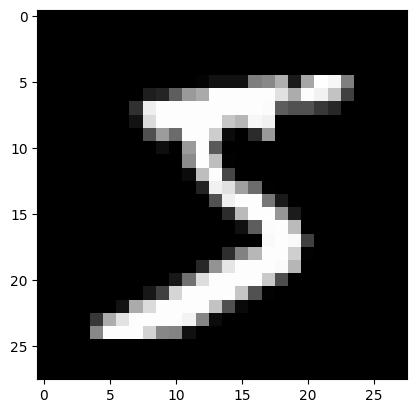

In [7]:
print(im_as_2D_array.shape)
plt.imshow(im_as_2D_array);

In [8]:
x_train_as_2D_arrays = x_train.reshape(60_000, 28, 28) # reshape all back

In [9]:
x_train_as_2D_arrays.shape

(60000, 28, 28)

In [10]:
del x_train_as_2D_arrays # delete, we don't need it anymore!

In [11]:
x_train.shape

(60000, 784)

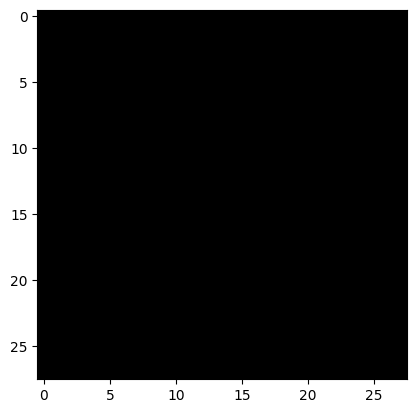

In [13]:
origin = np.zeros(784)
plt.imshow(origin.reshape(28, 28))

# Questions (images as vectors):

* What's the image which is the *origin* of the vector space $\mathbb{R}^{784}$ where the images live?

* What's its norm?

* What does the norm of any single image compute? I mean how can it be interpreted in terms of images.

* What happens when we multiply an image by a scalar? 0, 0.5, -1?

* What happens when we add, subtract two vectors representing images?
* What happens if we take the (arithmetic) mean ('average')?


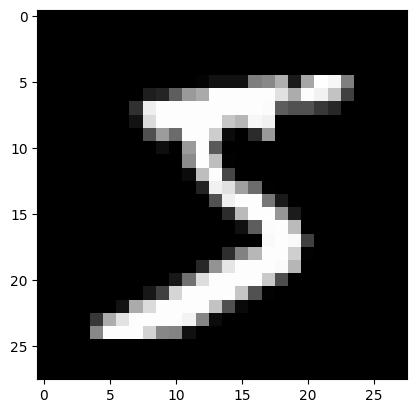

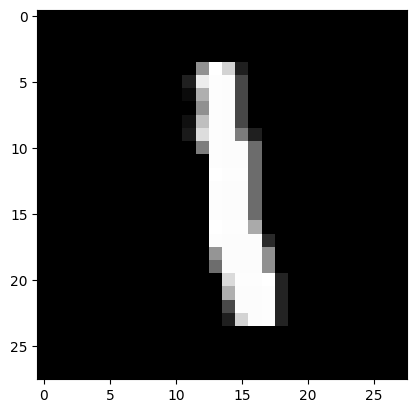

In [ ]:
im1, im2 = x_train[0], x_train[6]

for im in im1, im2:
    plt.imshow(im.reshape(IM_WIDTH, IM_WIDTH))
    plt.show()

In [ ]:
mean_im = (im1 + im2)/2

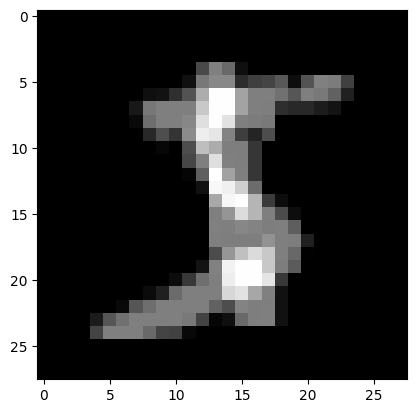

In [ ]:
plt.imshow(mean_im.reshape(28,28))

# Task 1: The mean image

Use the data reshaped to the 2-dimensional array, so that each element is a flat vector.

Plot the mean image for each label. Namely the arithmetic mean of all images with the same label.

This is very similar to an **exercise from last time**!

> np.mean works similarly to np.sum!

> Hint: use conditions/masks (you can also use y_train!). By masks I mean the arrays of True/False which we used for filtering values.


> Don't be afraid of using for loops (if the number of iterations is reletively small). Here you'll need to iterate over all possible label values -- but there aren't too many, so a for loop will not slow things down. It's important to avoid for loops to do heavy computations.

> How can we interpret the results? Any hint that people write some digits differently?



In [ ]:
'''
Outline:
for each label:
  select vectors corresponding to images with this label
  compute the mean vector using np.mean, careful about axis!
  reshape the result back as an image, and display
  make sure each result is displayed and not just the last one!
'''

# The Euclidean distance as a dissimilarity measure

The distance $$d(v,w) = \sqrt{\sum_{i=1}^d (v_i - w_i)^2} = \| v-w \|_2$$

> Remember that np.linalg.norm computes the norm ($\| v \|_2$) for us, which is just the distance from the origin (vector of zeros)

> TIP: If you have many vectors you need to specify the axis along which the norm is computed.


# Reminder: Examples of norm computations for many vectors (axis=?)

In [ ]:
ts = np.linspace(0, 2*np.pi, 10)
xy = np.array([np.cos(ts), np.sin(ts)]).T # just a bunch of points on a circle

In [ ]:
plt.scatter(xy.T[0], xy.T[1])
plt.axis('equal');

In [ ]:
# which axis do we use to compute the norm of each point
print(np.linalg.norm(xy))
print(np.linalg.norm(xy, axis=0))
print(np.linalg.norm(xy, axis=1)) # this looks good!

We can interpret the Euclidean distance as the norm of the image $(A-B)$, or more intuitively as the square root of the sum over all elements of $(A-B)^2$.

Let's take two images $A$ and $B$ and plot (imshow) $(A-B)^2$ to understand better what's hapenning!

> Can you interpret what you see?

# Intuition behind the Euclidan distance between images

In [ ]:
# First let's verify we get the same results
A = x_train[y_train==7][3]
B = x_train[y_train==7][12]
D = (A-B)**2
print(np.sqrt(D.sum()), np.linalg.norm(A-B))

In [ ]:
for im, name in zip([A,B,D],['A', 'B', '(A-B)**2']):
  # plt.imshow(im) # wrong shape!
  plt.imshow(im.reshape(28, 28))
  plt.title(name)
  plt.show()

# Optional Task 2 (important for later assignments)

Pick your favourite image and find, say, 5 **nearest images** to it. By which mean 5 images closest under the Euclidean distance to this image.

Are they really similar? Repeat for other favourite images.

> Btw. what's *the* nearest image?

> TIP: remember about np.argsort and array slicing! np.argsort gives you the indices such that if you index with them, you get a sorted result. Keep in mind you can call np.argsort on one array and index another array (provided the number of elements is the same).

> TIP: remember you can subtract a number -- or a vector! -- from an entire array of vectors! No loops!

In [ ]:
'''
OUTLINE:
select query vector (image) and show it
compute array of distances between query and each image in x_train
sort x_train using these distances (np.argsort - returns indices that "sort" an array)
take 5 initial ones in the sorted array
imshow these 5 after reshaping to images
'''



# Extra Task 3

We computed 10 representative images (each showing a different 'avarage' digit).

We would like to quantify if these images are good representatives. Intuitively the representative of a digit D should be surrounded by other images of D.

So we can check if the, say, $k = 20$ nearest neighbours have the same label.

> Is this what's really happening?

> How far can you push the parameter k? Does it work for 100? 1000?



# Extra Task 4

We could try to check the 10 representatives in another way.

From another angle, the representative of a digit D should be more similar (i.e. closer) to other images of digit D than images of other digits.

Can you verify this is true? (It's meant to be slightly open-ended.)

